In [1]:
# Bibliotecas básicas
import pandas as pd
import numpy as np
import random
import warnings
import hashlib

warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Estatística
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Modelagem (baselines da Etapa 1)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, precision_recall_curve, auc, confusion_matrix,
)

# Rastreabilidade de experimentos
import mlflow
import mlflow.sklearn
import dagshub

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Acesso aos helpers compartilhados em src/ (single source of truth)
import sys
sys.path.insert(0, "..")
from src.application.business_metrics import (
    VALOR_CLIENTE_LTV, CUSTO_RETENCAO,
    find_optimal_threshold, calculate_metrics,
)


In [2]:
# Test Size
TEST_SIZE = 0.2

## Setup de rastreabilidade (MLflow + DagsHub)

Toda a Etapa 1 é registrada em um experimento MLflow dedicado (`Churn-Predict-Telco-Etapa1-EDA`),
separado do experimento da Etapa 2 para não poluir o pipeline de comparação de modelos. As runs
incluem o hash MD5 do dataset (`dataset_version_md5`) para garantir rastreabilidade da versão dos
dados usada nesta análise.

> **Pré-requisito**: credenciais DagsHub configuradas via `dagshub login` ou variáveis de ambiente
> `MLFLOW_TRACKING_USERNAME` / `MLFLOW_TRACKING_PASSWORD`.


In [3]:
DATASET_PATH = "../data/dataset/telco_customer_churn.csv"
EXPERIMENT_NAME = "Churn-Predict-Telco-Etapa1-EDA"
REPO_OWNER = "JosueJNLui"
REPO_NAME = "fiap-mlet-challenge-fase-1"

# Configurar MLflow + DagsHub
dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)
mlflow.set_experiment(EXPERIMENT_NAME)

# Hash MD5 do dataset (versão dos dados usada nesta análise)
with open(DATASET_PATH, "rb") as f:
    DATASET_VERSION = hashlib.md5(f.read()).hexdigest()
print(f"Dataset MD5: {DATASET_VERSION}")


Accessing as zonetti

Initialized MLflow to track repo "JosueJNLui/fiap-mlet-challenge-fase-1"

Repository JosueJNLui/fiap-mlet-challenge-fase-1 initialized!

Dataset MD5: 0f9de68e012bd3aed5fa7cdc9fc421af


## Métrica de negócio

Em churn, os custos de erro são **assimétricos**: deixar um cliente sair (FN) custa o LTV
inteiro, enquanto oferecer retenção desnecessária a quem ficaria (FP) custa apenas o
cupom/desconto. F1 trata os dois erros com igual peso e, por isso, é insuficiente como
métrica única.

Adotamos **lucro líquido** como métrica de negócio com valores arbitrados (mas plausíveis):

- LTV de um cliente retido: **R$ 500**
- Custo da oferta de retenção: **R$ 100**

`Lucro = TP × (LTV − CustoRetenção) − FP × CustoRetenção − FN × LTV`. O threshold de
classificação é otimizado para maximizar essa função (não fixado em 0.5).


In [4]:
# Helpers de negócio (find_optimal_threshold, calculate_metrics) e constantes
# (VALOR_CLIENTE_LTV, CUSTO_RETENCAO) vêm de src/application/business_metrics.py.
# Single source of truth compartilhada com modeling.ipynb e models-comparison.ipynb.
print(f"LTV=R$ {VALOR_CLIENTE_LTV} | Custo retencao=R$ {CUSTO_RETENCAO}")


LTV=R$ 500 | Custo retencao=R$ 100


In [5]:
df_raw = pd.read_csv('../data/dataset/telco_customer_churn.csv')

df = df_raw.copy()

# Informações gerais sobre o dataset

print(f"Formato dos dados: {df.shape}")
print(f"\nPrimeiras linhas do dataset:")
print(df.head(10))

print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
print(df.info())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
print(df.describe())

Formato dos dados: (7043, 21)

Primeiras linhas do dataset:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... Dev

## Validação de schema (data readiness)

Antes de qualquer análise, validamos o DataFrame contra `RAW_TELCO_SCHEMA` (pandera). 
O schema vive em `src/application/data_schemas.py` e fixa contratos de tipo, vocabulário e ranges 
para as 21 colunas do CSV bruto. Falhar aqui significa que o dataset divergiu do esperado em treino — 
data readiness é um passo formal, não uma inspeção visual.

In [6]:
from src.application.data_schemas import RAW_TELCO_SCHEMA

RAW_TELCO_SCHEMA.validate(df_raw, lazy=True)
print(f"Schema raw OK: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas validadas.")

Schema raw OK: 7043 linhas x 21 colunas validadas.


In [7]:
# Análise de valores ausentes
print("=== ANÁLISE DE MISSING VALUES ===\n")

missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
    print(missing_values)
    
    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
    plt.xlabel('Porcentagem de Missing Values (%)')
    plt.title('Distribuição de Missing Values por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado!")

=== ANÁLISE DE MISSING VALUES ===

Nenhum missing value detectado!


=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:
target
0    5174
1    1869
Name: count, dtype: int64

Percentual:
Sem churn (0): 73.46%
Com churn (1): 26.54%


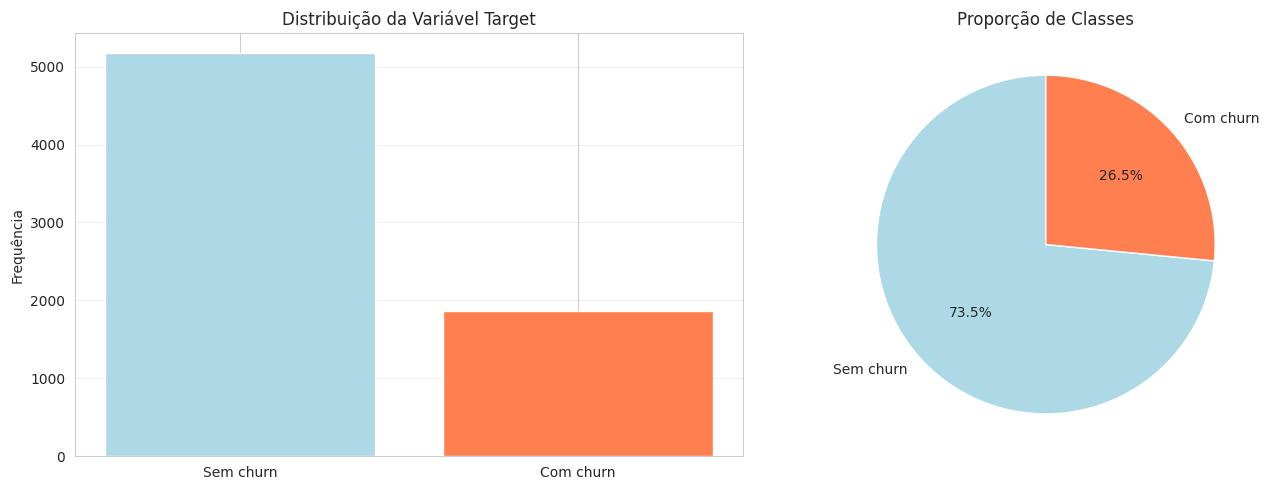


Ratio min/max: 0.36  |  Classe minoritária: 26.54%

⚠️  Dataset DESBALANCEADO (~73% Não / ~27% Sim, ratio 0.37). Estratégias adotadas:
    1. class_weight='balanced' nos modelos lineares (Etapa 1).
    2. Threshold otimizado por lucro líquido (não fixado em 0.5).
    3. K-Fold estratificado (5 folds) para estimativas estáveis nos baselines.


In [8]:
# Cria target binária PRESERVANDO 'Churn' (string) para visualizações posteriores
df['target'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Converte TotalCharges para numérico — os 11 registros com tenure=0 viram NaN.
# A imputação acontece apenas no pré-processamento de modelagem (célula adiante).
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)
print("\nPercentual:")
for idx, pct in target_percentages.items():
    label = "Sem churn" if idx == 0 else "Com churn"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(['Sem churn', 'Com churn'], target_counts.values, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)
axes[1].pie(target_counts.values, labels=['Sem churn', 'Com churn'],
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')
plt.tight_layout()
plt.show()

# Avaliação honesta do desbalanceamento
ratio = target_counts.min() / target_counts.max()
minority_pct = target_percentages.min()
print(f"\nRatio min/max: {ratio:.2f}  |  Classe minoritária: {minority_pct:.2f}%")
print(
    "\n⚠️  Dataset DESBALANCEADO (~73% Não / ~27% Sim, ratio 0.37). Estratégias adotadas:\n"
    "    1. class_weight='balanced' nos modelos lineares (Etapa 1).\n"
    "    2. Threshold otimizado por lucro líquido (não fixado em 0.5).\n"
    "    3. K-Fold estratificado (5 folds) para estimativas estáveis nos baselines."
)


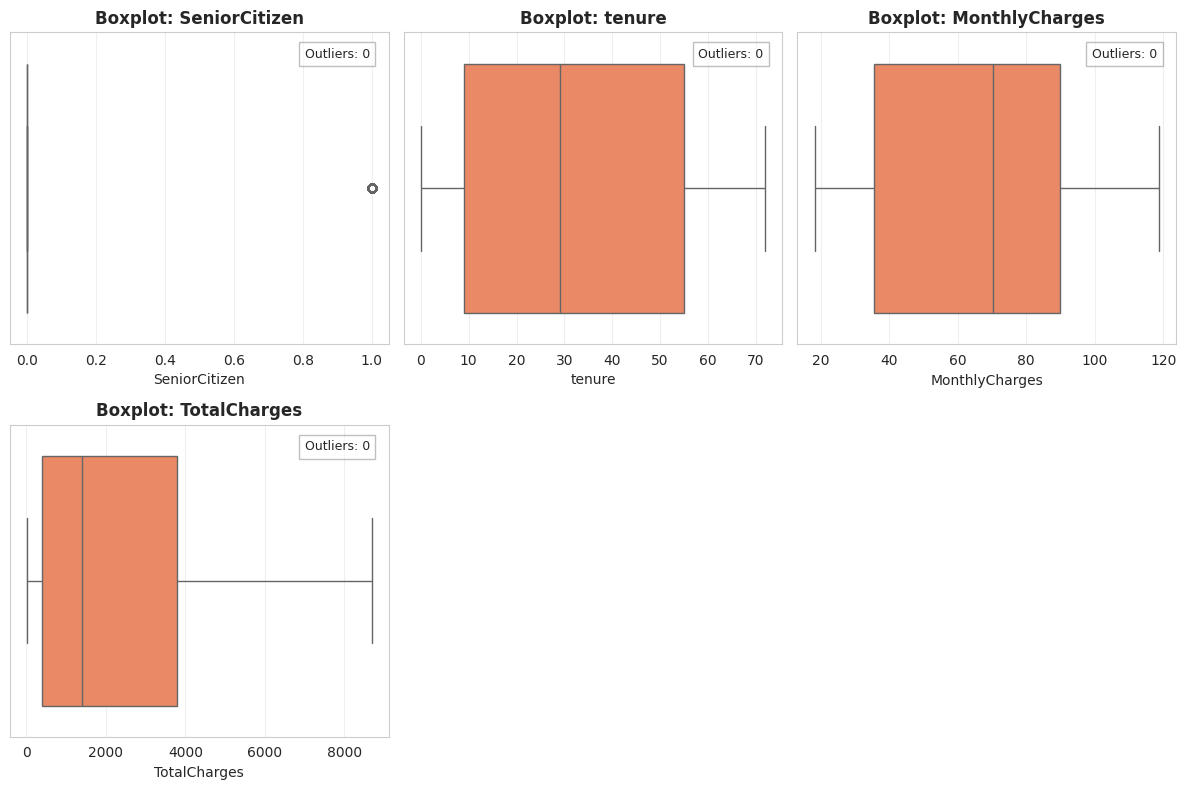

In [9]:
# Colunas numéricas (excluindo id e target)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['target'])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [10]:
print("=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===\n")

anomalies = []

# 1. SeniorCitizen (deve ser 0 ou 1)
senior_anomalies = df[~df['SeniorCitizen'].isin([0, 1])]
if len(senior_anomalies) > 0:
    anomalies.append(('SeniorCitizen', len(senior_anomalies), 'Valores fora de {0, 1}'))

# 2. tenure (deve estar entre 0 e 72 meses)
tenure_anomalies = df[(df['tenure'] < 0) | (df['tenure'] > 72)]
if len(tenure_anomalies) > 0:
    anomalies.append(('tenure', len(tenure_anomalies), f'Fora do intervalo [0, 72] — min={df["tenure"].min()}, max={df["tenure"].max()}'))

# 3. MonthlyCharges (deve ser positivo)
monthly_anomalies = df[df['MonthlyCharges'] <= 0]
if len(monthly_anomalies) > 0:
    anomalies.append(('MonthlyCharges', len(monthly_anomalies), f'Valores <= 0 — min={df["MonthlyCharges"].min()}'))

# 4. TotalCharges (é object; verificar valores não numéricos / em branco)
total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
tc_invalid = total_charges_numeric.isna().sum()
if tc_invalid > 0:
    anomalies.append(('TotalCharges', tc_invalid, 'Valores não numéricos ou em branco'))
tc_negative = (total_charges_numeric < 0).sum()
if tc_negative > 0:
    anomalies.append(('TotalCharges', tc_negative, f'Valores negativos — min={total_charges_numeric.min()}'))

# 5. gender (deve ser Male ou Female)
gender_anomalies = df[~df['gender'].isin(['Male', 'Female'])]
if len(gender_anomalies) > 0:
    anomalies.append(('gender', len(gender_anomalies), f'Valores inesperados: {df["gender"].unique()}'))

# 6. target (deve ser 0 ou 1 após conversão)
target_anomalies = df[~df['target'].isin([0, 1])]
if len(target_anomalies) > 0:
    anomalies.append(('target', len(target_anomalies), 'Valores fora de {0, 1}'))

# 7. Colunas binárias Yes/No — verificar valores inesperados
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    col_anomalies = df[~df[col].isin(['Yes', 'No'])]
    if len(col_anomalies) > 0:
        anomalies.append((col, len(col_anomalies), f'Valores inesperados: {df[col].unique()}'))

# --- Registros duplicados ---
duplicated_count = df.duplicated().sum()

# --- Relatório ---
if anomalies:
    print(f"⚠️ Anomalias encontradas em {len(anomalies)} coluna(s):\n")
    for col, count, desc in anomalies:
        print(f"  • {col}: {count} registro(s) — {desc}")
    total_anomaly_records = sum(c for _, c, _ in anomalies)
    print(f"\n  Total de ocorrências de anomalia: {total_anomaly_records}")
else:
    print("✅ Nenhuma anomalia detectada nas verificações de domínio.")

print(f"\n📋 Registros duplicados: {duplicated_count}")
if duplicated_count > 0:
    print(f"   ({duplicated_count / len(df) * 100:.2f}% do dataset)")
else:
    print("   Nenhum registro duplicado encontrado.")

=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===

⚠️ Anomalias encontradas em 1 coluna(s):

  • TotalCharges: 11 registro(s) — Valores não numéricos ou em branco

  Total de ocorrências de anomalia: 11

📋 Registros duplicados: 0
   Nenhum registro duplicado encontrado.


=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===

        Coluna  Skewness  Kurtosis         Interpretação
 SeniorCitizen     1.834     1.363 Assimétrica à direita
        tenure     0.240    -1.387                Normal
MonthlyCharges    -0.221    -1.257                Normal
  TotalCharges     0.962    -0.232 Assimétrica à direita


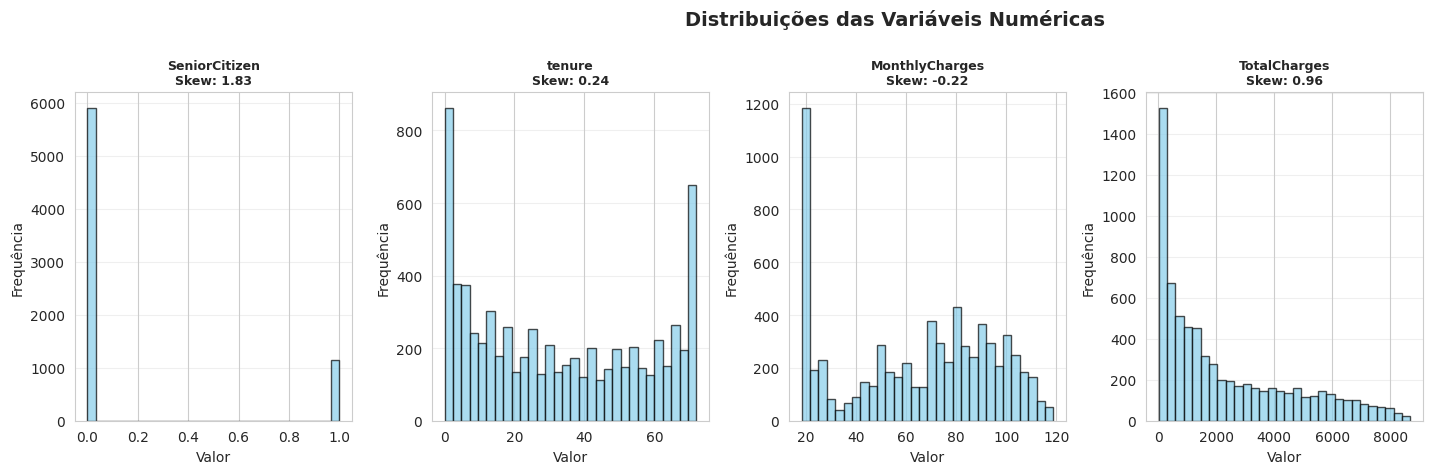

In [11]:
# Análise de distribuições
print("=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===\n")

distribution_stats = []
for col in numeric_cols:
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    distribution_stats.append({
        'Coluna': col,
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurtosis, 3),
        'Interpretação': 'Normal' if abs(skewness) < 0.5 else ('Assimétrica à direita' if skewness > 0 else 'Assimétrica à esquerda')
    })

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

# Visualizar distribuições
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}\nSkew: {df[col].skew():.2f}', fontsize=9, fontweight='bold')
        axes[idx].set_xlabel('Valor')
        axes[idx].set_ylabel('Frequência')
        axes[idx].grid(axis='y', alpha=0.3)

# Remover subplots vazios
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuições das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

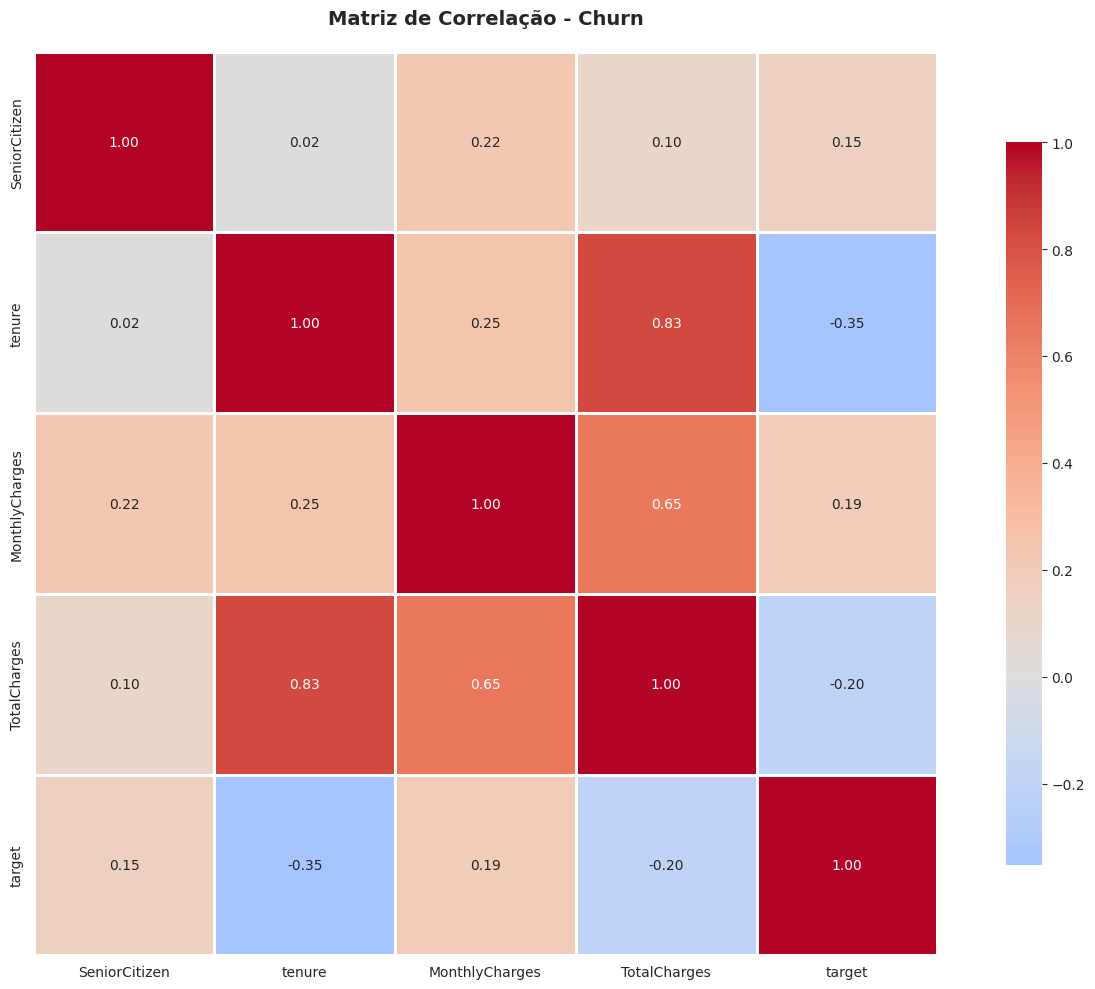

=== CORRELAÇÕES COM A VARIÁVEL TARGET ===

target            1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199484
tenure           -0.352229
Name: target, dtype: float64

=== MULTICOLINEARIDADE (Correlação entre features) ===
Pares de features com correlação > 0.7:

Feature 1    Feature 2  Correlação
   tenure TotalCharges       0.826

⚠️ Alta correlação entre features pode causar multicolinearidade!

INTERPRETAÇÃO E DECISÃO
TotalCharges ≈ MonthlyCharges × tenure (feature derivada por construção).
Por isso a alta correlação tenure–TotalCharges é estrutural, não acidental.

Decisões para a modelagem:
  • Manter as três variáveis (tenure, MonthlyCharges, TotalCharges) — Logistic
    Regression com regularização L2 lida bem com colinearidade moderada.
  • Aplicar np.log1p em TotalCharges para reduzir a assimetria à direita
    (alinhado com src/application/preprocessing.py em produção).
  • Em modelos baseados em árvore (Etapa 2) a colinearidade é irre

In [12]:
# Matriz de correlação apenas para colunas numéricas
corr_numeric = df.select_dtypes(include=[np.number]).corr()

# Visualizar matriz de correlação
plt.figure(figsize=(14, 10))
sns.heatmap(corr_numeric, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Churn', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlações fortes com o target
print("=== CORRELAÇÕES COM A VARIÁVEL TARGET ===\n")
target_corr = corr_numeric['target'].sort_values(ascending=False)
print(target_corr)

# Identificar pares de features com alta correlação (possível multicolinearidade)
print("\n=== MULTICOLINEARIDADE (Correlação entre features) ===")
print("Pares de features com correlação > 0.7:\n")

high_corr_pairs = []
for i in range(len(corr_numeric.columns)):
    for j in range(i+1, len(corr_numeric.columns)):
        if abs(corr_numeric.iloc[i, j]) > 0.7 and corr_numeric.columns[i] != 'target' and corr_numeric.columns[j] != 'target':
            high_corr_pairs.append({
                'Feature 1': corr_numeric.columns[i],
                'Feature 2': corr_numeric.columns[j],
                'Correlação': round(corr_numeric.iloc[i, j], 3)
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlação', ascending=False)
    print(high_corr_df.to_string(index=False))
    print("\n⚠️ Alta correlação entre features pode causar multicolinearidade!")
else:
    print("✓ Nenhuma correlação forte detectada entre features (excluindo target)")

# === DECISÃO sobre multicolinearidade tenure × TotalCharges ===
print("\n" + "=" * 60)
print("INTERPRETAÇÃO E DECISÃO")
print("=" * 60)
print(
    "TotalCharges ≈ MonthlyCharges × tenure (feature derivada por construção).\n"
    "Por isso a alta correlação tenure–TotalCharges é estrutural, não acidental.\n\n"
    "Decisões para a modelagem:\n"
    "  • Manter as três variáveis (tenure, MonthlyCharges, TotalCharges) — Logistic\n"
    "    Regression com regularização L2 lida bem com colinearidade moderada.\n"
    "  • Aplicar np.log1p em TotalCharges para reduzir a assimetria à direita\n"
    "    (alinhado com src/application/preprocessing.py em produção).\n"
    "  • Em modelos baseados em árvore (Etapa 2) a colinearidade é irrelevante."
)


In [13]:
# Pré-processamento mínimo para os baselines da Etapa 1.
# Trabalhamos sobre uma cópia (df_model) para preservar `df` para análises posteriores.
df_model = df.drop(columns=['customerID', 'Churn']).copy()

# Imputa os 11 valores ausentes em TotalCharges (clientes com tenure=0)
mask = df_model['TotalCharges'].isna()
df_model.loc[mask, 'TotalCharges'] = (
    df_model.loc[mask, 'MonthlyCharges'] * df_model.loc[mask, 'tenure']
)

# log1p em TotalCharges (decisão da célula anterior — assimetria à direita)
df_model['TotalCharges'] = np.log1p(df_model['TotalCharges'])

# One-hot encoding (drop_first para evitar dummy trap)
categorical_cols = df_model.select_dtypes(include=['object', 'category']).columns.tolist()
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=['target'])
y = df_encoded['target'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

print(f"Shape X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Features após one-hot: {X.shape[1]}")
print(f"Distribuição target treino: {y_train.value_counts(normalize=True).round(3).to_dict()}")


Shape X_train: (5634, 30)  |  X_test: (1409, 30)
Features após one-hot: 30
Distribuição target treino: {0: 0.735, 1: 0.265}


In [14]:
# =============================================================================
# BASELINES DA ETAPA 1 — DummyClassifier + Logistic Regression
# =============================================================================
# Cada baseline é avaliado com K-Fold estratificado (5 folds) sobre X_train,
# threshold otimizado por fold para maximizar lucro líquido, e métricas finais
# reportadas no hold-out (X_test) com a mediana dos thresholds.
# Tudo registrado no MLflow (experimento Churn-Predict-Telco-Etapa1-EDA).
#
# Comparação rigorosa de Random Forest, XGBoost e MLP fica em
# notebooks/modeling.ipynb (Etapa 2).
# =============================================================================

CV_FOLDS = 5
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

dataset_params = {
    "dataset_path": DATASET_PATH,
    "dataset_version_md5": DATASET_VERSION,
    "n_train": int(X_train.shape[0]),
    "n_test": int(X_test.shape[0]),
    "n_features": int(X_train.shape[1]),
    "target_rate_train": round(float(y_train.mean()), 4),
    "test_size": TEST_SIZE,
    "random_state": SEED,
    "cv_folds": CV_FOLDS,
}

baselines = {
    "baseline_dummy": DummyClassifier(strategy="most_frequent", random_state=SEED),
    "baseline_logreg": LogisticRegression(
        max_iter=1000, random_state=SEED, class_weight="balanced", solver="lbfgs"
    ),
}

metric_keys = [
    "accuracy", "f1_score", "precision", "recall", "roc_auc", "pr_auc",
    "lucro_liquido_BRL", "custo_churn_evitado_BRL", "custo_falso_positivo_BRL",
    "custo_churn_perdido_BRL", "optimal_threshold",
]

resumo = []
for run_name, model_template in baselines.items():
    with mlflow.start_run(run_name=run_name):
        model_class = type(model_template).__name__
        mlflow.log_params({**dataset_params, "model": model_class})
        mlflow.log_params({
            f"hp_{k}": v for k, v in model_template.get_params().items()
            if isinstance(v, (int, float, str, bool, type(None)))
        })

        fold_metrics = {k: [] for k in metric_keys}
        fold_thresholds = []

        for fold_idx, (tr, va) in enumerate(skf.split(X_train, y_train), start=1):
            X_tr, X_va = X_train.iloc[tr], X_train.iloc[va]
            y_tr, y_va = y_train.iloc[tr], y_train.iloc[va]

            model = type(model_template)(**model_template.get_params())
            model.fit(X_tr, y_tr)

            # DummyClassifier 'most_frequent' devolve probabilidade constante,
            # mas o método existe e o threshold ótimo cai naturalmente em 0.0/1.0.
            y_proba = model.predict_proba(X_va)[:, 1]
            t_opt = find_optimal_threshold(y_va.values, y_proba)
            fold_thresholds.append(t_opt)
            m = calculate_metrics(y_va.values, y_proba, t_opt)
            for k in metric_keys:
                fold_metrics[k].append(m[k])

        for k in metric_keys:
            mlflow.log_metric(f"cv_mean_{k}", float(np.mean(fold_metrics[k])))
            mlflow.log_metric(f"cv_std_{k}", float(np.std(fold_metrics[k])))

        # Reajuste no X_train completo e avaliação no hold-out
        final_model = type(model_template)(**model_template.get_params())
        final_model.fit(X_train, y_train)
        y_test_proba = final_model.predict_proba(X_test)[:, 1]
        t_test = float(np.median(fold_thresholds))
        test_metrics = calculate_metrics(y_test.values, y_test_proba, t_test)
        for k, v in test_metrics.items():
            mlflow.log_metric(f"test_{k}", float(v))

        try:
            mlflow.sklearn.log_model(final_model, name="model")
        except TypeError:
            mlflow.sklearn.log_model(final_model, artifact_path="model")

        resumo.append({
            "modelo": run_name,
            "cv_lucro_BRL_mean": float(np.mean(fold_metrics["lucro_liquido_BRL"])),
            "cv_lucro_BRL_std": float(np.std(fold_metrics["lucro_liquido_BRL"])),
            "cv_roc_auc_mean": float(np.mean(fold_metrics["roc_auc"])),
            "cv_pr_auc_mean": float(np.mean(fold_metrics["pr_auc"])),
            "cv_recall_mean": float(np.mean(fold_metrics["recall"])),
            "test_lucro_BRL": float(test_metrics["lucro_liquido_BRL"]),
            "test_roc_auc": float(test_metrics["roc_auc"]),
            "test_recall": float(test_metrics["recall"]),
            "test_threshold": t_test,
        })

resumo_df = pd.DataFrame(resumo).set_index("modelo").round(4)
print("=" * 80)
print("BASELINES DA ETAPA 1 — Resumo (CV 5-fold + hold-out)")
print("=" * 80)
print(resumo_df.to_string())
print(
    "\nObs.: comparação rigorosa com Random Forest, XGBoost e MLP fica em "
    "notebooks/modeling.ipynb (Etapa 2)."
)


2026/05/03 21:48:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run baseline_dummy at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/12/runs/cdce7e8e210f45efb1e031bed676e419
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/12


2026/05/03 21:49:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run baseline_logreg at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/12/runs/42df2120946446f68ec181c71555867d
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/12
BASELINES DA ETAPA 1 — Resumo (CV 5-fold + hold-out)
                 cv_lucro_BRL_mean  cv_lucro_BRL_std  cv_roc_auc_mean  cv_pr_auc_mean  cv_recall_mean  test_lucro_BRL  test_roc_auc  test_recall  test_threshold
modelo                                                                                                                                                          
baseline_dummy           -149500.0            0.0000           0.5000          0.6327          0.0000       -187000.0        0.5000       0.0000          0.0100
baseline_logreg            64840.0         2361.0167           0.8497          0.6706          0.9398         80200.0        0.8475       0.9492          0.2278

Obs.: comparação rigorosa com Random Forest, XG

> **Nota — trajetória do threshold para produção.** Os valores acima (`threshold=0.2278`, lucro hold-out R$ 80.200) representam o **baseline da Etapa 1** (CV 5-fold sobre o LogReg simples). A otimização final por curva de lucro acontece em `notebooks/modeling.ipynb` (célula "Pipeline de produção (LogReg) — Etapa 3"), que ajusta o threshold para `0.2080` e eleva o lucro hold-out para R$ 81.200. É esse threshold (e a Pipeline empacotada `v3` registrada com alias `@production`) que vai para a API.

## Análise exploratória complementar

Nesta seção, vamos aprofundar a análise do dataset sem repetir as etapas já realizadas no EDA inicial. O foco será em `TotalCharges`, relações com `Churn`, variáveis categóricas, variáveis numéricas e correlações.

In [15]:
# df_work é apenas um apelido — TotalCharges já foi convertido na célula 4
df_work = df.copy()


In [16]:
print("=== VERIFICAÇÃO DE TotalCharges ===")
print(f"Valores inválidos em TotalCharges: {df_work['TotalCharges'].isna().sum()}")
display(df_work[df_work["TotalCharges"].isna()].head())

=== VERIFICAÇÃO DE TotalCharges ===
Valores inválidos em TotalCharges: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,target
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,0
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,0
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,0
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,0


## Análise descritiva de TotalCharges

Aqui avaliamos a distribuição de `TotalCharges` após a conversão para numérico. Essa variável costuma ser importante porque combina tempo de contrato e valor mensal, ajudando a explicar comportamento de churn.

In [17]:
print("=== ESTATÍSTICAS DESCRITIVAS DE TotalCharges ===")
display(df_work["TotalCharges"].describe())

print("\n=== ASSIMETRIA E CURTOSE ===")
print(f"Skewness: {df_work['TotalCharges'].skew():.4f}")
print(f"Kurtosis: {df_work['TotalCharges'].kurtosis():.4f}")

=== ESTATÍSTICAS DESCRITIVAS DE TotalCharges ===


count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64


=== ASSIMETRIA E CURTOSE ===
Skewness: 0.9616
Kurtosis: -0.2318


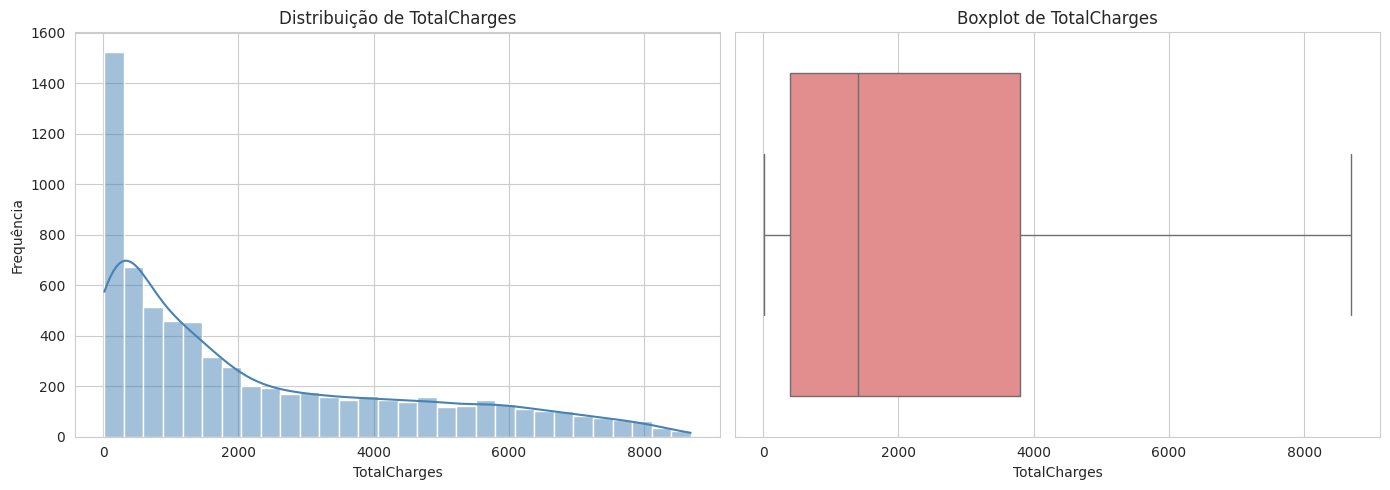

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_work["TotalCharges"].dropna(), bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribuição de TotalCharges")
axes[0].set_xlabel("TotalCharges")
axes[0].set_ylabel("Frequência")

sns.boxplot(x=df_work["TotalCharges"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot de TotalCharges")
axes[1].set_xlabel("TotalCharges")

plt.tight_layout()
plt.show()

## TotalCharges por churn

Agora vamos comparar `TotalCharges` entre clientes com e sem churn. Essa análise ajuda a entender se clientes que saem tendem a ter padrões diferentes de gasto acumulado.

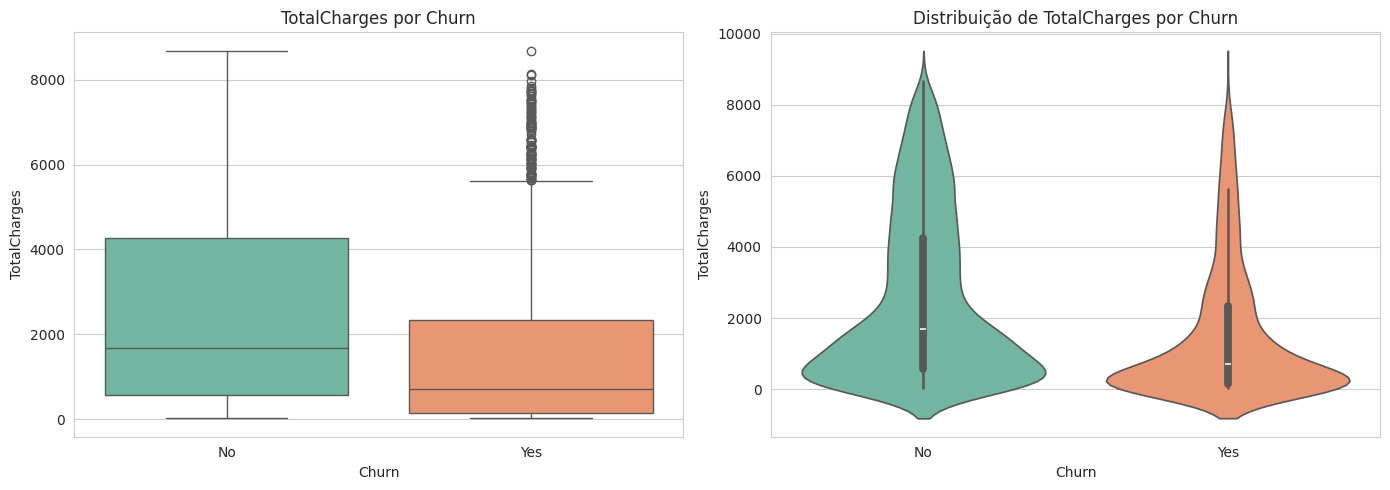

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_work, x="Churn", y="TotalCharges", ax=axes[0], palette="Set2")
axes[0].set_title("TotalCharges por Churn")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("TotalCharges")

sns.violinplot(data=df_work, x="Churn", y="TotalCharges", ax=axes[1], palette="Set2")
axes[1].set_title("Distribuição de TotalCharges por Churn")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("TotalCharges")

plt.tight_layout()
plt.show()

In [20]:
print("=== MÉDIA DE TotalCharges POR CHURN ===")
display(
    df_work.groupby("Churn")["TotalCharges"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

=== MÉDIA DE TotalCharges POR CHURN ===


,count,mean,median,std,min,max
Churn,,,,,,
No,5163,2555.34,1683.60,2329.46,18.80,8672.45
Yes,1869,1531.80,703.55,1890.82,18.85,8684.80


## Variáveis categóricas e churn

Nesta parte, vamos comparar a proporção de churn nas principais variáveis categóricas. O objetivo é detectar padrões que possam indicar maior risco de cancelamento.

<Figure size 1000x400 with 0 Axes>

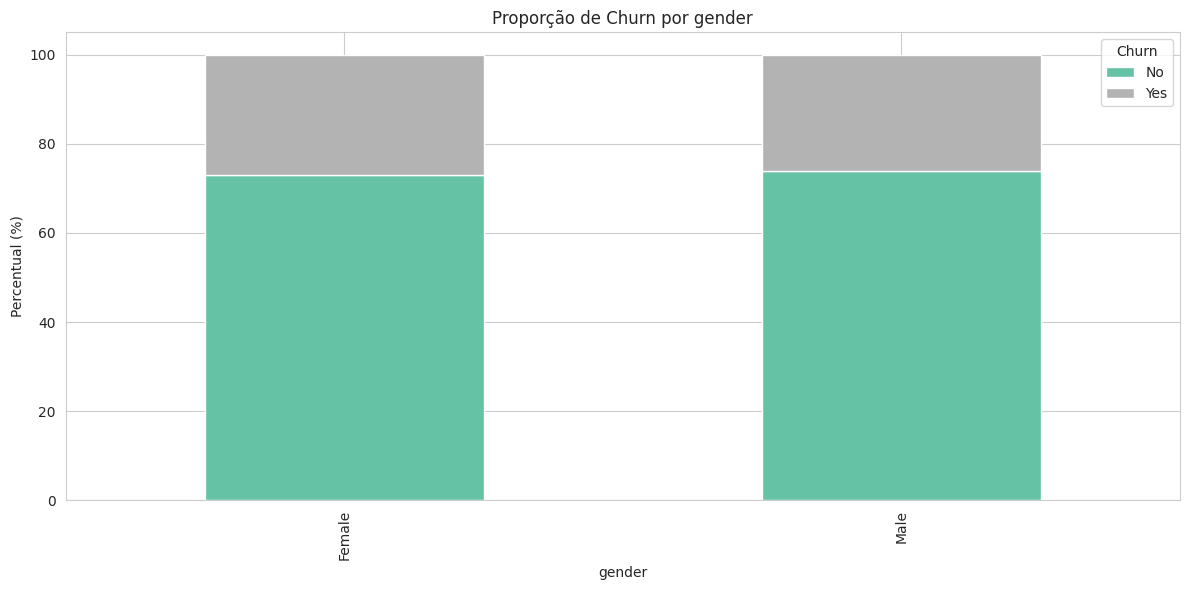

<Figure size 1000x400 with 0 Axes>

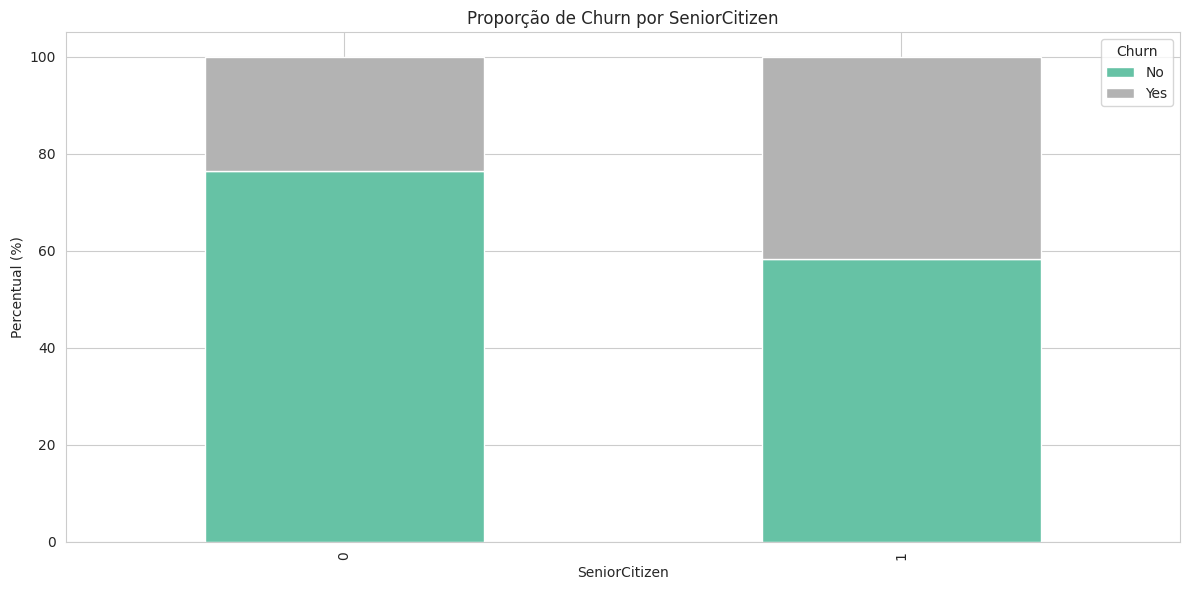

<Figure size 1000x400 with 0 Axes>

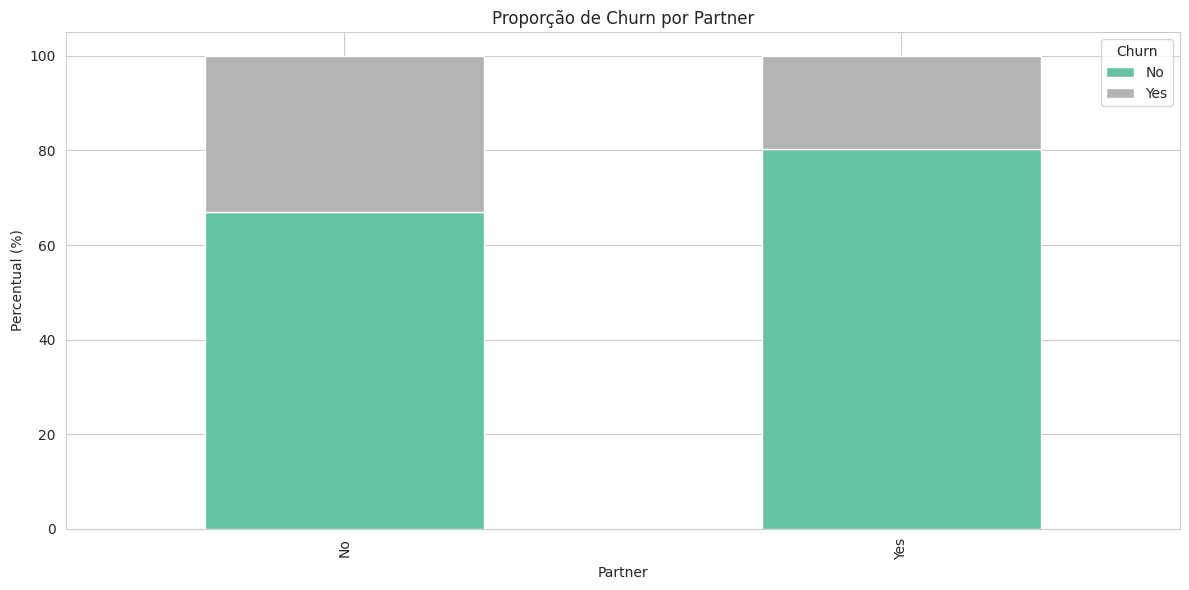

<Figure size 1000x400 with 0 Axes>

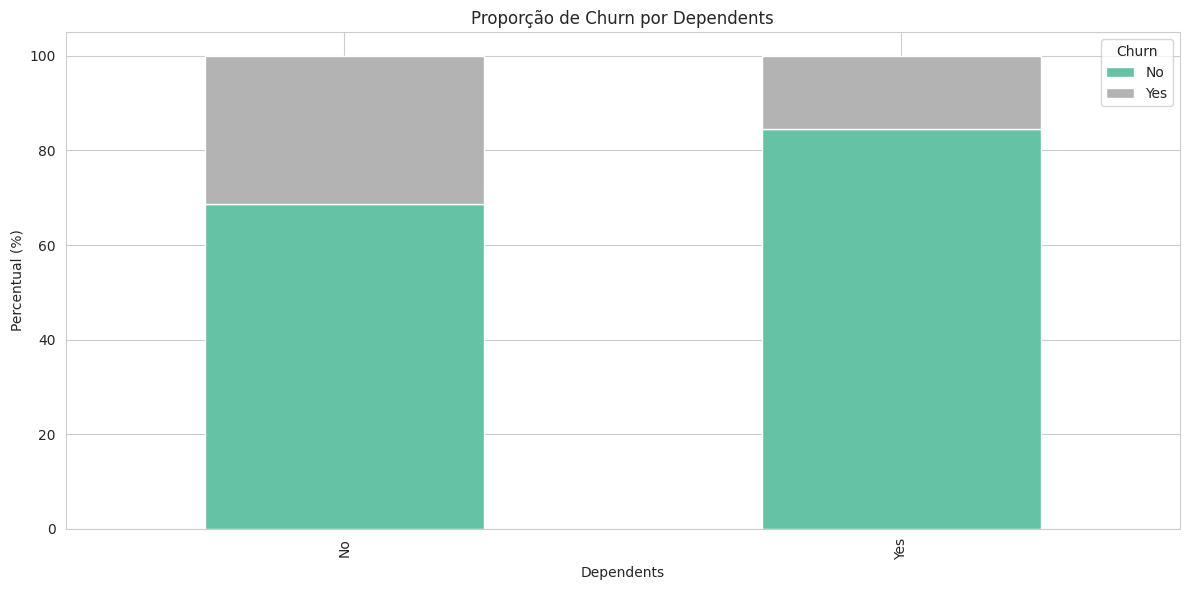

<Figure size 1000x400 with 0 Axes>

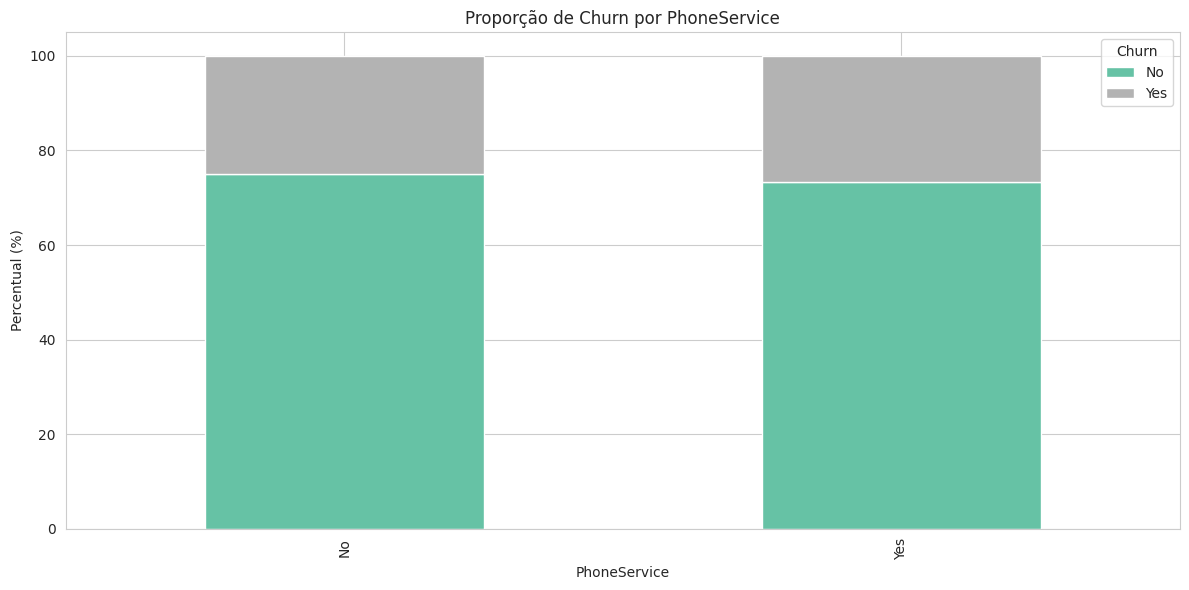

<Figure size 1000x400 with 0 Axes>

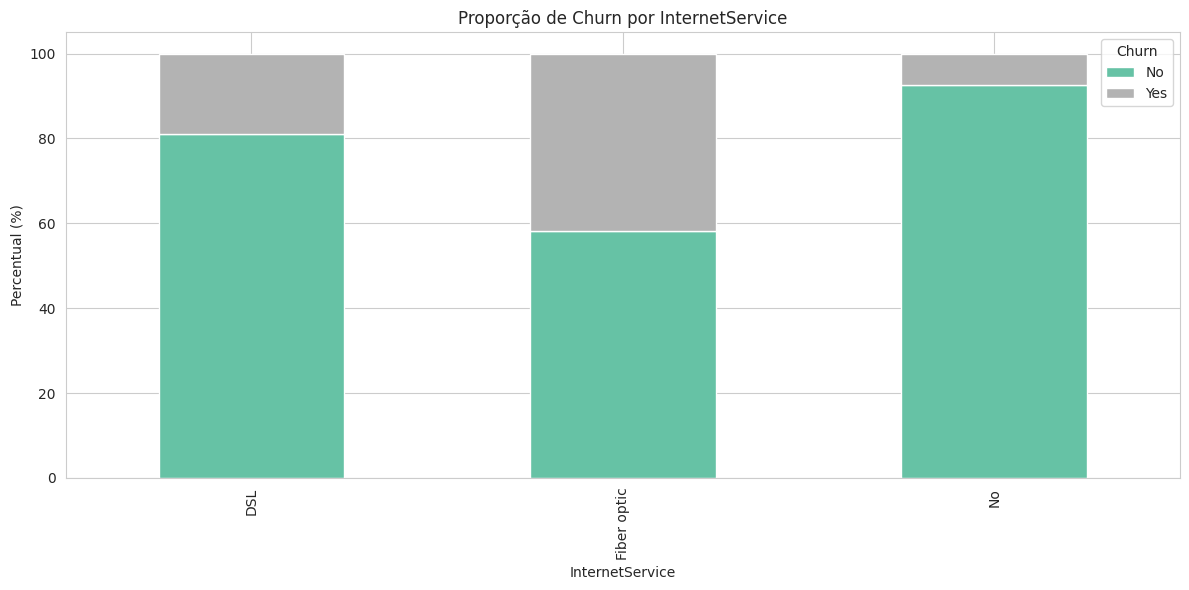

<Figure size 1000x400 with 0 Axes>

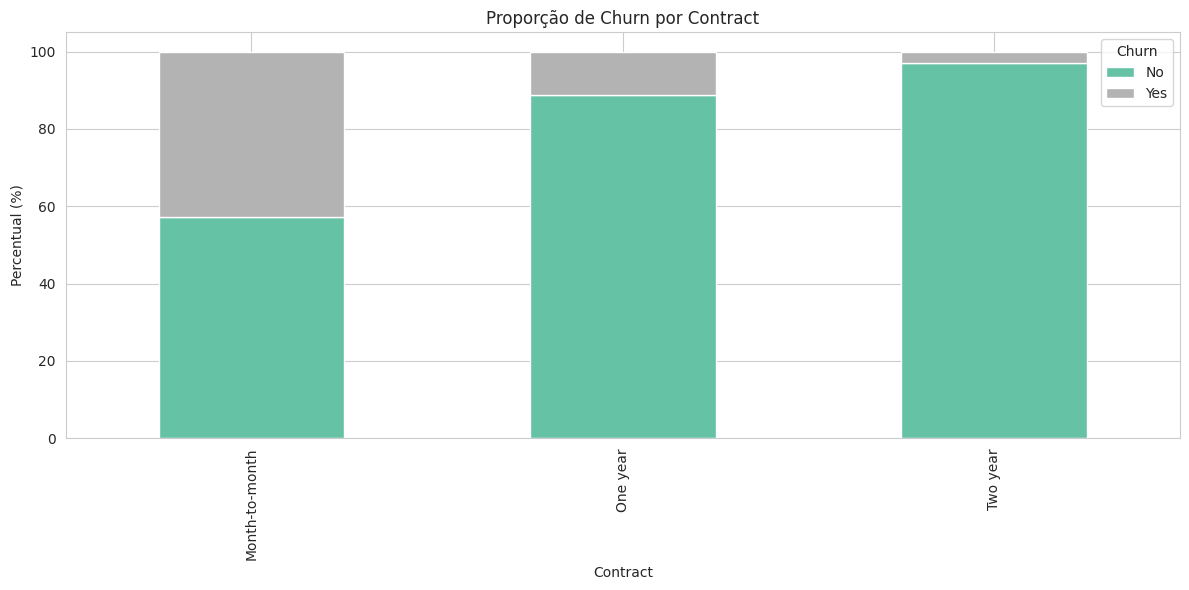

<Figure size 1000x400 with 0 Axes>

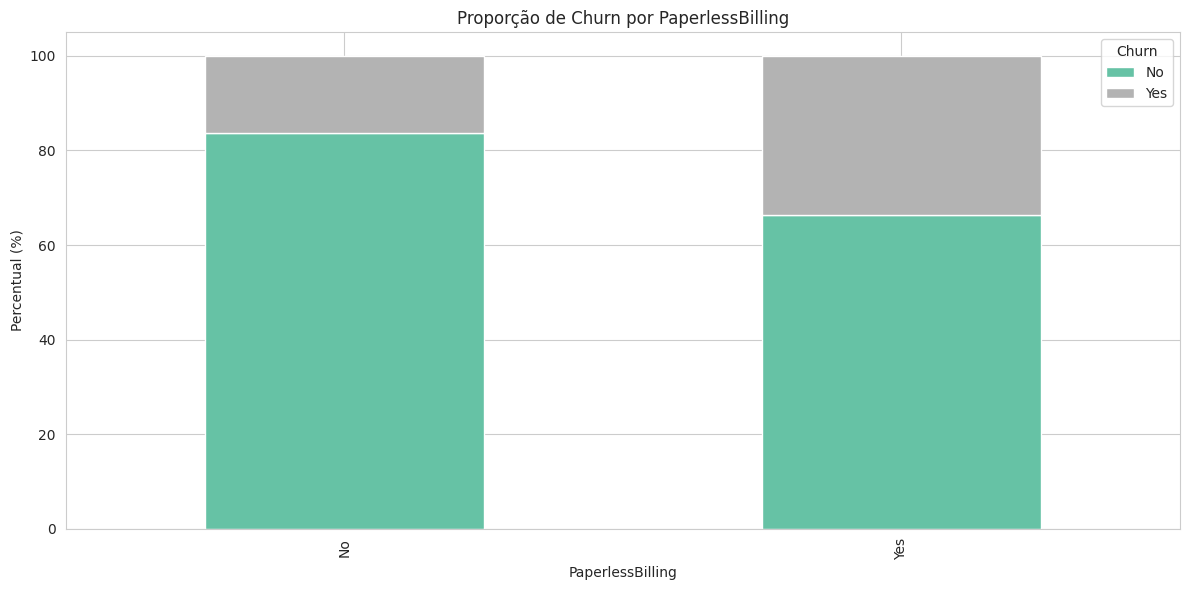

<Figure size 1000x400 with 0 Axes>

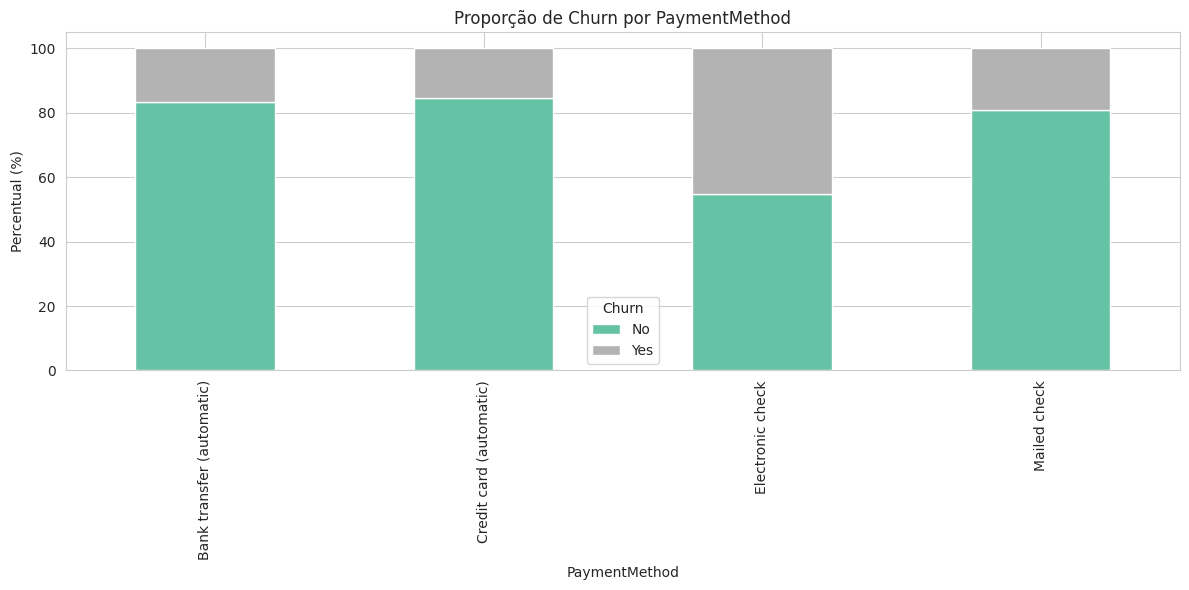

In [21]:
categorical_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "InternetService",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    churn_prop = pd.crosstab(df_work[col], df_work["Churn"], normalize="index") * 100
    churn_prop.plot(kind="bar", stacked=True, colormap="Set2")
    plt.title(f"Proporção de Churn por {col}")
    plt.xlabel(col)
    plt.ylabel("Percentual (%)")
    plt.legend(title="Churn")
    plt.tight_layout()
    plt.show()

In [22]:
print("=== TABELAS DE PROPORÇÃO DE CHURN ===")
for col in ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]:
    print(f"\n--- {col} ---")
    display(pd.crosstab(df_work[col], df_work["Churn"], normalize="index").round(4))

=== TABELAS DE PROPORÇÃO DE CHURN ===

--- Contract ---


Churn,No,Yes
Contract,,
Month-to-month,0.5729,0.4271
One year,0.8873,0.1127
Two year,0.9717,0.0283



--- InternetService ---


Churn,No,Yes
InternetService,,
DSL,0.8104,0.1896
Fiber optic,0.5811,0.4189
No,0.9260,0.0740



--- PaymentMethod ---


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.8329,0.1671
Credit card (automatic),0.8476,0.1524
Electronic check,0.5471,0.4529
Mailed check,0.8089,0.1911



--- PaperlessBilling ---


Churn,No,Yes
PaperlessBilling,,
No,0.8367,0.1633
Yes,0.6643,0.3357


## Variáveis numéricas e churn

Aqui vamos observar como `tenure`, `MonthlyCharges` e `TotalCharges` se comportam entre os grupos de churn. Essas variáveis costumam mostrar diferenças relevantes entre clientes que permanecem e clientes que cancelam.

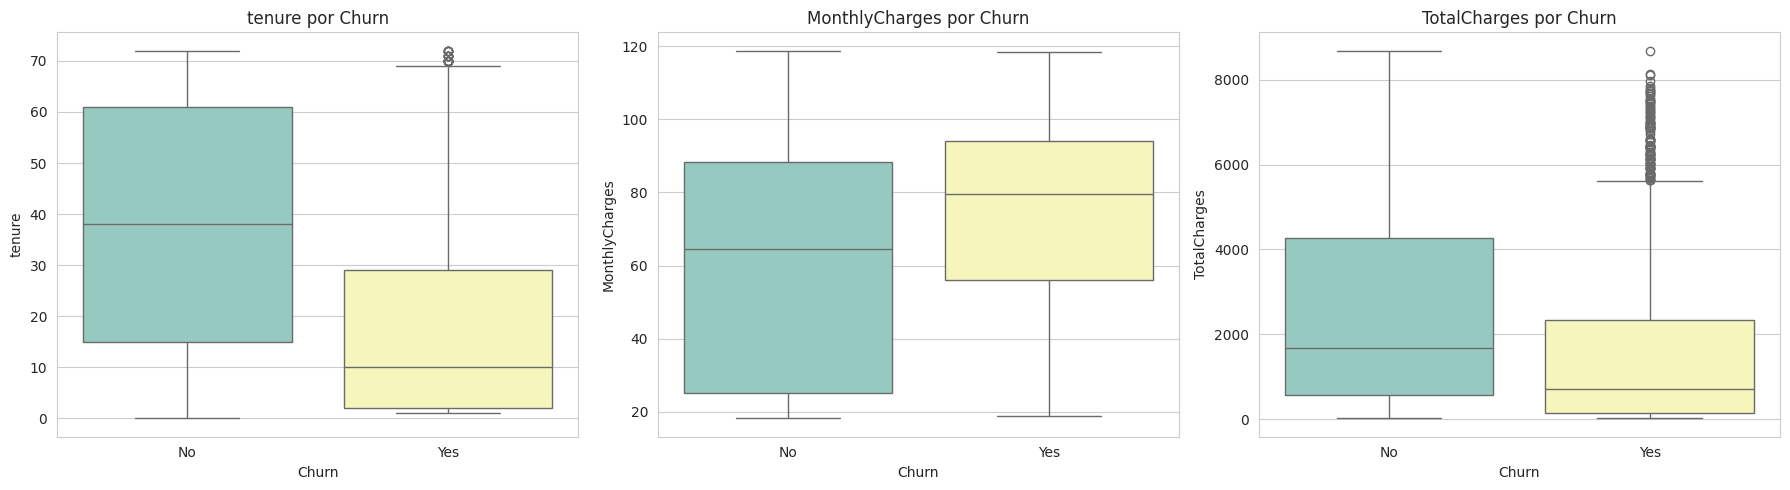

In [23]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_work, x="Churn", y=col, ax=axes[i], palette="Set3")
    axes[i].set_title(f"{col} por Churn")
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [24]:
print("=== RESUMO NUMÉRICO POR CHURN ===")
display(
    df_work.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]]
    .agg(["mean", "median", "std"])
    .round(2)
)

=== RESUMO NUMÉRICO POR CHURN ===


tenure               MonthlyCharges               TotalCharges           \
        mean median    std           mean median    std         mean   median   
Churn                                                                           
No     37.57   38.0  24.11          61.27  64.43  31.09      2555.34  1683.60   
Yes    17.98   10.0  19.53          74.44  79.65  24.67      1531.80   703.55   

                
           std  
Churn           
No     2329.46  
Yes    1890.82

## Correlação entre variáveis numéricas

Esta etapa mede a força da relação linear entre as variáveis numéricas. Ela ajuda a identificar dependências e possíveis redundâncias antes da modelagem.

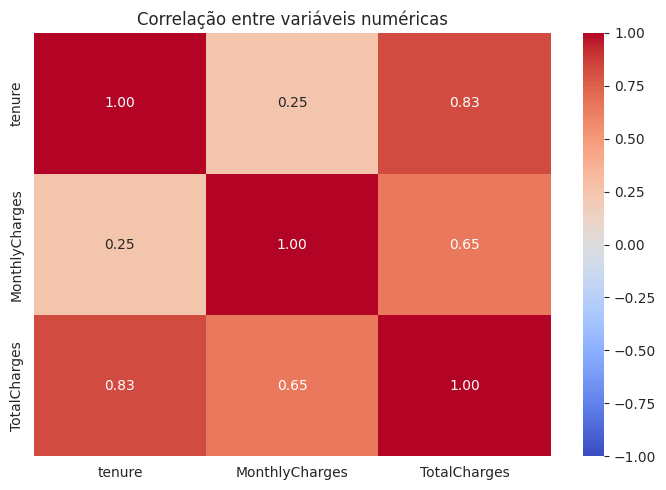

In [25]:
corr = df_work[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

In [26]:
print("=== MATRIZ DE CORRELAÇÃO ===")
display(corr.round(4))

=== MATRIZ DE CORRELAÇÃO ===


,tenure,MonthlyCharges,TotalCharges
tenure,1.0000,0.2479,0.8259
MonthlyCharges,0.2479,1.0000,0.6511
TotalCharges,0.8259,0.6511,1.0000


## Interpretação parcial

Os gráficos acima permitem comparar padrões de gasto, tempo de permanência e tipo de contrato entre clientes que cancelam e os que permanecem.  


In [27]:
# Para os testes numéricos abaixo, removemos as 11 linhas com TotalCharges ausente
df_work = df.dropna(subset=['TotalCharges']).copy()
print(f'Formato após dropna em TotalCharges: {df_work.shape}')
print(f"Distribuição do target: {df_work['target'].value_counts().to_dict()}")


Formato após dropna em TotalCharges: (7032, 22)
Distribuição do target: {0: 5163, 1: 1869}


=== RESUMO DAS VARIÁVEIS POR TARGET ===
       tenure               MonthlyCharges               TotalCharges  \
         mean median    std           mean median    std         mean   
target                                                                  
0       37.65   38.0  24.08          61.31  64.45  31.09      2555.34   
1       17.98   10.0  19.53          74.44  79.65  24.67      1531.80   

                          
         median      std  
target                    
0       1683.60  2329.46  
1        703.55  1890.82  


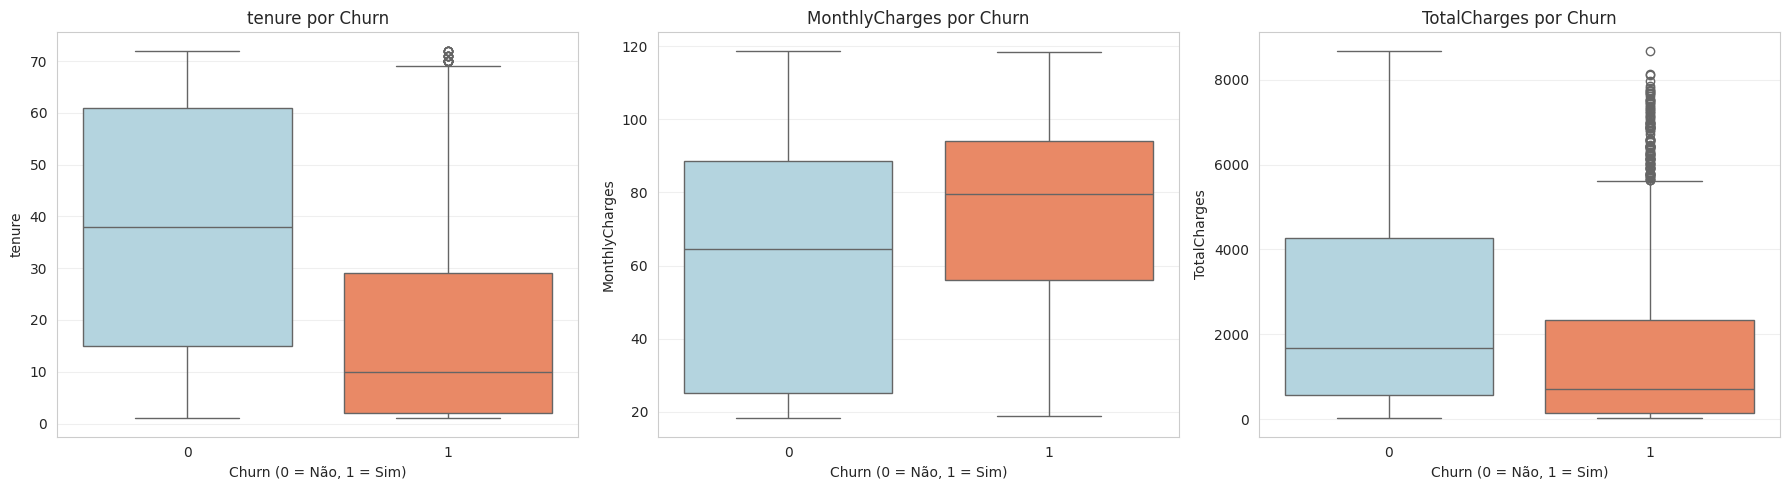

In [28]:
# Comparação das variáveis numéricas por churn
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

summary_churn = df_work.groupby('target')[numeric_cols].agg(['mean', 'median', 'std']).round(2)
print('=== RESUMO DAS VARIÁVEIS POR TARGET ===')
print(summary_churn)

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df_work, x='target', y=col, ax=ax, palette=['lightblue', 'coral'])
    ax.set_title(f'{col} por Churn')
    ax.set_xlabel('Churn (0 = Não, 1 = Sim)')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# Teste de diferença de distribuição entre grupos (Mann-Whitney U, não-paramétrico).
# Aplicamos correção de Bonferroni para múltiplos testes.
from scipy.stats import mannwhitneyu

resultados = []
for col in numeric_cols:
    g0 = df_work[df_work['target'] == 0][col]
    g1 = df_work[df_work['target'] == 1][col]
    stat, pvalue = mannwhitneyu(g0, g1, alternative='two-sided')
    resultados.append({
        'feature': col,
        'U_statistic': float(stat),
        'p_value_raw': float(pvalue),
    })

mw_df = pd.DataFrame(resultados)
reject, p_adj, _, _ = multipletests(mw_df['p_value_raw'], method='bonferroni')
mw_df['p_value_bonferroni'] = p_adj
mw_df['rejeita_H0_(α=0.05)'] = reject

print('=== Mann-Whitney U por feature numérica vs target (com Bonferroni) ===')
print(mw_df.to_string(index=False))


=== Mann-Whitney U por feature numérica vs target (com Bonferroni) ===
       feature  U_statistic   p_value_raw  p_value_bonferroni  rejeita_H0_(α=0.05)
        tenure    7154668.0 6.043047e-211       1.812914e-210                 True
MonthlyCharges    3663498.5  8.467195e-54        2.540159e-53                 True
  TotalCharges    6288982.0  1.995985e-84        5.987955e-84                 True


## Análise das variáveis numéricas

Após tratar `TotalCharges`, comparo as variáveis numéricas mais relevantes entre clientes com e sem churn. Essa etapa ajuda a entender se há diferença de comportamento entre os grupos antes da modelagem.

Os boxplots mostram como `tenure`, `MonthlyCharges` e `TotalCharges` se distribuem por classe. Em geral, clientes com churn tendem a apresentar menor permanência e padrões diferentes de cobrança ao longo do tempo.

## Conclusões da Etapa 1

**Dados.** 7.043 registros, 21 colunas; nenhum missing nominal, mas 11 valores em
`TotalCharges` são strings vazias para clientes com `tenure=0` (clientes novos cuja
fatura ainda não fechou). Imputamos por `MonthlyCharges × tenure` apenas no pipeline
de modelagem; mantivemos `NaN` na visualização para honestidade.

**Desbalanceamento.** Target 73% / 27% (ratio 0.37). Estratégia: `class_weight='balanced'`
no LogReg + threshold otimizado por lucro líquido (não fixado em 0.5).

**Drivers de churn confirmados estatisticamente.** Mann-Whitney U com correção de
Bonferroni sobre `tenure`, `MonthlyCharges` e `TotalCharges` rejeita H₀ em todos os
casos — diferenças entre os grupos são significativas.

**Multicolinearidade.** `tenure` e `TotalCharges` correlacionam ~0.83 (esperado:
`TotalCharges ≈ MonthlyCharges × tenure`). Decisão: manter as três features e aplicar
`np.log1p` em `TotalCharges` (assimetria à direita) — alinhado a
`src/application/preprocessing.py`.

**Métrica de negócio.** Lucro líquido com LTV=R$500 e custo de retenção=R$100. F1
sozinho não basta porque trata FP e FN como equivalentes, o que aqui é falso (FN
custa o LTV inteiro).

**Baselines.** `DummyClassifier(most_frequent)` e `LogisticRegression(class_weight='balanced')`
treinados com K-Fold (5 folds) sobre o treino e avaliados no hold-out. Resultados
registrados no MLflow (experimento `Churn-Predict-Telco-Etapa1-EDA`) com hash do
dataset, hiperparâmetros e 11 métricas (técnicas + negócio). LogReg supera o Dummy
em lucro líquido — esperado, mas validado.

**Ponte para a Etapa 2.** A comparação rigorosa de Random Forest, XGBoost, MLP
(PyTorch) com 10-Fold pareado e teste de Friedman+Nemenyi vive em
`notebooks/modeling.ipynb`. Ali também ocorre a busca de arquitetura do MLP, o
registro de modelos serializados e a seleção do modelo final.
